In [2]:
dataset_location = "./fwdfwdupdate"
print("Train set:")
!head -n 5 {dataset_location}/dataset/_annotations.all.jsonl.small
#print("\nValidation set:")
#!head -n 5 {dataset_location}/dataset/_annotations.valid.jsonl

Train set:
{"prefix": "move large blue cube onto large blue sphere<loc0406><loc0482><loc0053><loc0101><loc0051><loc0083>", "suffix": "<loc0508><loc0462><loc0074><loc0085><loc0085><loc0140><loc0521><loc0501><loc0054><loc0085><loc0085><loc0140>", "action_text": "move large blue cube onto large blue sphere", "camera_extrinsic": [[[-0.7592566013336182, 0.6507914066314697, 0.0, 0.0], [0.3005320131778717, 0.35062068700790405, -0.8869868516921997, 0.10643845796585083], [-0.577243447303772, -0.6734505891799927, -0.4617947041988373, 0.5751268863677979]]], "camera_intrinsic": [[[410.02923583984375, 0.0, 224.0], [0.0, 410.02923583984375, 224.0], [0.0, 0.0, 1.0]]], "obj_start_pose": [[-0.09932111203670502, -0.17632822692394257, 0.019999999552965164, 0.41686341166496277, -0.0, -0.0, -0.9089691638946533]], "obj_end_pose": [[-0.0070929452776908875, -0.01729106903076172, 0.10447657853364944, 0.41686341166496277, -0.0, -0.0, -0.9089691638946533]], "tcp_start_pose": [[-0.008612102828919888, -0.035581968

In [3]:
import cv2
import json
from typing import List
import re

def read_n_lines(file_path: str, n: int) -> List[str]:
    with open(file_path, 'r') as file:
        lines = [next(file).strip() for _ in range(n)]
    return lines

def parse_trajectory_tokens(caption):
  caption = caption.strip("\n")
  if ";" in caption:
    raise ValueError
  pattern = r"(?:<loc\d{4}>)+ ([\w\s\-]+)$"
  match = re.search(pattern, caption)
  #print(f"Matched words: {match.group(1)}")
  if match:
    return match
  else:
    return ""

images = []
lines = read_n_lines(f"{dataset_location}/dataset/_annotations.all.jsonl.small", 1)
first = json.loads(lines[0])

#CLASSES = first.get('prefix').replace("detect ", "").split(" ; ")
for line in lines:
    data = json.loads(line)
    #image = cv2.imread(f"{dataset_location}/dataset/{data.get('image')}")
    #(h, w, _) = image.shape

    suffix = data.get('suffix')
    prefix = data.get('prefix')
    #match = parse_trajectory_tokens(suffix)
    print(prefix)
    

move large blue cube onto large blue sphere<loc0406><loc0482><loc0053><loc0101><loc0051><loc0083>



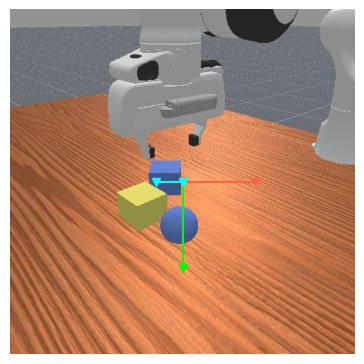

done!


In [12]:
import numpy as np
from scipy.spatial.transform import Rotation
import matplotlib.pyplot as plt
from PIL import Image
import io
import html
import base64
from IPython.display import display, HTML


text = "<loc0625><loc0762><loc0468><loc0724><loc0384><loc0679><loc0375><loc0632><loc0430><loc0587><loc0587> 1"
action_text = data.get('prefix')

# === Extrinsic matrix
# From camera coordinates to world coordinates.
# First rotation, then translation
# t is camera center in world coordinates.
def camera_to_world(t, rot):
    ext = np.eye(4)
    ext[0:3, 0:3] = rot
    ext[0:3, 3] = t
    return ext

def world_to_camera(t: np.ndarray, rot: np.ndarray):
    """
    World 3d to camera 3d.
    t: (3) translation
    rot: (3,3) rotation
    """
    ext = np.eye(4)
    ext[0:3, 0:3] = rot.T
    ext[0:3, 3] = -rot.T @ t
    return ext



def project(point_3d: np.ndarray, proj: np.ndarray):
    """ 
    Multiply by projection matrix in homogenous coordinates.
    
    point_3d: (3) 
    proj: (3, 4) """
    p3d = np.ones((4))
    p3d[:3] = point_3d
    p2d = proj @ p3d # (3, 4) x (4, 1)
    p2d = p2d / p2d[2]
    return p2d[:2]

# === How to project
# 1) world to camera
# 2) pinhole
# 3) intrinsics
# 4) divide by last component in homogeneous coordinates

# === Intrinsics
pix = 1/448 # pixel size
c_x = 448 * 0.5
c_y = 448 * 0.5
intrinsics = np.array(
    [[1/pix, 0, c_x],
     [0, 1/pix, c_y],
     [0, 0, 1]]
)

# === Extrinsics
t_rot = [0, 0, -4, 0, 0, 0]
rot = Rotation.from_euler(
    "xyz", np.array(t_rot[3:])
).as_matrix()
t = t_rot[:3]
ext = world_to_camera(t, rot)
pinhole = np.eye(4)[:3, :4]
proj = intrinsics @ pinhole @ ext # (3, 3) x (3, 4), x (4, 4)



# === robot extrinsics = [tx, ty, tz, angle_x, angle_y, angle_z], x=r, y=g, z=b
# Translation and rotation move world to robot position
robot_extrinsics = [0, 0, -4, 0, 0, 0]
# Rotation with 3 Euler angles. See scipy documentation
rotation = Rotation.from_euler(
    "xyz", np.array(robot_extrinsics[3:])
).as_matrix()
translation = robot_extrinsics[:3]
robot_ext = world_to_camera(translation, rotation)

# === robot local transform
robot_local = [0, 0, 0, 0, np.pi/8, 0]
rotation = Rotation.from_euler(
    "xyz", np.array(robot_local[3:])
).as_matrix()
translation = robot_local[:3]
robot_loc = world_to_camera(translation, rotation)


def render_example_trajectory(image, caption):
    image_height = 448
    image_width = 448
    
    # Pattern to extract numbers inside <loc####> tags
    loc_strings = re.findall(r"<loc(\d{4})>", caption)
    num_position_tokens = len(loc_strings)
    loc_strings_pairs = loc_strings[:(num_position_tokens//2)*2]
    loc_numbers = [int(x) for x in loc_strings_pairs]
    loc_h = [x/1024*image_height for x in loc_numbers[::2]]
    loc_w = [x/1024*image_width for x in loc_numbers[1::2]]
    curve_2d_short = curve_2d = np.array([np.stack((loc_w, loc_h), axis=1)])

    env_id = 0
    x, y = curve_2d[env_id, :, 0].tolist(), curve_2d[env_id, :, 1].tolist()

    pixel_width, pixel_height = 448, 448
    dpi = 100
    figsize = (pixel_width / dpi, pixel_height / dpi)
    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    ax.imshow(image)
    ax.axis('off')
    #ax.plot(curve_2d_short[env_id,:1,0], curve_2d_short[env_id, :1,1],'.-', color='lime')
    
    # === plot coordinate system (=robot space)
    o = np.array([0, 0, 0])
    x = np.array([1, 0, 0])
    y = np.array([0, 1, 0])
    z = np.array([0, 0, 1])
    total_proj = proj @ robot_loc

    o = project(o, total_proj)
    x = project(x, total_proj)
    y = project(y, total_proj)
    z = project(z, total_proj)
    
    line_x = np.stack((o, x)) # (n_points, xy)
    line_y = np.stack((o, y))
    line_z = np.stack((o, z))
    ax.plot(line_x[:, 0], line_x[:, 1],'v-', color='tomato')
    ax.plot(line_y[:, 0], line_y[:, 1],'v-', color='lime')
    ax.plot(line_z[:, 0], line_z[:, 1],'v-', color='aqua')

    with io.BytesIO() as buffer:
        fig.savefig(buffer, format='jpeg',bbox_inches='tight', dpi=dpi)
        image_b64 = str(base64.b64encode(buffer.getvalue()), "utf-8")
        res_str =  f"data:image/jpeg;base64,{image_b64}"
    plt.close(fig)
    return f"""
<div style="display: inline-flex; align-items: center; justify-content: center;">
    <img style="width:224px; height:224px;" src="{res_str}" />
    <p style="width:256px; margin:10px; font-size:small;">{html.escape(caption)}</br>{html.escape(caption)}</p>

</div>
"""

html_out = ""
#for image, _, caption in make_predictions(validation_data_iterator(), num_examples=1, batch_size=1):
#  html_out += render_example(image, caption)

caption = data.get('prefix')
image = Image.open(f"{dataset_location}/dataset/{data.get('image')}")
html_out += render_example_trajectory(image, caption)
display(HTML(html_out))
print("done!")

In [13]:
matches[:, 0]

NameError: name 'matches' is not defined